In [16]:
from pathlib import Path
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    f1_score, precision_score, recall_score, roc_auc_score,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)
RANDOM_STATE = 42
PREDICTION_BATCH_SIZE = 20_000

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TEST_FILE = PROJECT_ROOT / "dataset/processed/test.parquet"
FEATURE_FILE = PROJECT_ROOT / "artifacts/feature_selection/selected_features.json"
MODEL_FOLDER = PROJECT_ROOT / "artifacts/models"
ATTACK_MODEL_FILE = PROJECT_ROOT / "artifacts/attack_type_model/random_forest_attack_type.joblib"
EVALUATION_FOLDER = PROJECT_ROOT / "artifacts/evaluation"

model_files = {
    "Random Forest": MODEL_FOLDER / "random_forest.joblib",
    "Decision Tree": MODEL_FOLDER / "decision_tree.joblib",
    "K-Nearest Neighbors": MODEL_FOLDER / "k-nearest_neighbors.joblib",
    "Attack-type Random Forest": ATTACK_MODEL_FILE,
}

files = pd.DataFrame([
    {"model": name, "exists": path.exists(),
     "size_mb": round(path.stat().st_size / 1024**2, 2) if path.exists() else None}
    for name, path in model_files.items()
]).set_index("model")
print("Saved model files")
display(files)

required = [TEST_FILE, FEATURE_FILE, model_files["Random Forest"], ATTACK_MODEL_FILE]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))

Saved model files


,exists,size_mb
model,,
Random Forest,True,16.85
Decision Tree,True,0.14
K-Nearest Neighbors,True,2.10
Attack-type Random Forest,True,15.71


## 1. Load the test data

In [17]:
feature_report = json.loads(FEATURE_FILE.read_text(encoding="utf-8"))
features = feature_report["selected_features"]
test = pd.read_parquet(
    TEST_FILE, columns=features + ["is_attack", "attack_label", "attack_category"]
)
x_test = test[features]
y_binary = test["is_attack"]
y_category = test["attack_category"].astype(str)

print(f"Test rows:       {len(test):,}")
print(f"Input features:  {len(features)}")
print(f"Memory usage:    {test.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print("\nSelected features:")
for number, feature in enumerate(features, start=1):
    print(f"{number:2}. {feature}")

print("\nBinary class distribution:")
binary_counts = y_binary.value_counts().rename(index={0: "Benign", 1: "Attack"})
display(pd.DataFrame({
    "rows": binary_counts, "percent": binary_counts / len(test) * 100
}).round(2))

print("Attack-category distribution:")
category_counts = y_category.value_counts()
display(pd.DataFrame({
    "rows": category_counts, "percent": category_counts / len(test) * 100
}).round(3))

Test rows:       499,596
Input features:  20
Memory usage:    52.1 MB

Selected features:
 1. Packet Length Variance
 2. Packet Length Std
 3. Avg Bwd Segment Size
 4. Bwd Packet Length Std
 5. Average Packet Size
 6. Destination Port
 7. Fwd IAT Max
 8. Fwd IAT Std
 9. Subflow Bwd Bytes
10. Flow IAT Std
11. Fwd Packet Length Max
12. Idle Min
13. Init_Win_bytes_backward
14. Fwd IAT Total
15. Avg Fwd Segment Size
16. Total Length of Fwd Packets
17. Init_Win_bytes_forward
18. Fwd IAT Mean
19. Flow IAT Mean
20. Min Packet Length

Binary class distribution:


,rows,percent
is_attack,,
Benign,414451,82.96
Attack,85145,17.04


Attack-category distribution:


,rows,percent
attack_category,,
BENIGN,414451,82.957
DoS Hulk,34569,6.919
DDoS,25603,5.125
PortScan,18139,3.631
DoS GoldenEye,2056,0.412
FTP-Patator,1186,0.237
DoS slowloris,1075,0.215
DoS Slowhttptest,1046,0.209
SSH-Patator,644,0.129


## 2. Binary Intrusion Detection: benign or attack

In [18]:
binary_models = {}
for name in ["Random Forest", "Decision Tree", "K-Nearest Neighbors"]:
    path = model_files[name]
    if not path.exists():
        print(f"Skipping {name}: saved model was not found")
        continue

    model = joblib.load(path)
    if hasattr(model, "n_jobs"):
        model.n_jobs = 1
    if hasattr(model, "named_steps") and "kneighborsclassifier" in model.named_steps:
        model.named_steps["kneighborsclassifier"].n_jobs = 1
    binary_models[name] = model

    print(f"\n{name}")
    print(f"  Python type:       {type(model).__name__}")
    print(f"  Learned classes:   {list(model.classes_)}")
    print(f"  Expected features: {model.n_features_in_}")
    assert model.n_features_in_ == len(features)
    assert set(model.classes_) == {0, 1}

print(f"\nSuccessfully loaded {len(binary_models)} binary model(s).")


Random Forest
  Python type:       RandomForestClassifier
  Learned classes:   [np.int8(0), np.int8(1)]
  Expected features: 20

Decision Tree
  Python type:       DecisionTreeClassifier
  Learned classes:   [np.int8(0), np.int8(1)]
  Expected features: 20

K-Nearest Neighbors
  Python type:       Pipeline
  Learned classes:   [np.int8(0), np.int8(1)]
  Expected features: 20

Successfully loaded 3 binary model(s).


In [19]:
def predict_in_batches(model, data):
    predictions, probabilities = [], []
    positive_class = list(model.classes_).index(1)
    for start in range(0, len(data), PREDICTION_BATCH_SIZE):
        batch = data.iloc[start:start + PREDICTION_BATCH_SIZE]
        batch_probabilities = model.predict_proba(batch)
        predictions.append(model.classes_[np.argmax(batch_probabilities, axis=1)])
        probabilities.append(batch_probabilities[:, positive_class])
    return np.concatenate(predictions), np.concatenate(probabilities)


binary_results = []
binary_outputs = {}

for name, model in binary_models.items():
    start = time.perf_counter()
    predictions, attack_probability = predict_in_batches(model, x_test)
    prediction_seconds = time.perf_counter() - start

    assert len(predictions) == len(test)
    binary_results.append({
        "model": name,
        "accuracy": accuracy_score(y_binary, predictions),
        "precision": precision_score(y_binary, predictions, zero_division=0),
        "recall": recall_score(y_binary, predictions, zero_division=0),
        "f1_score": f1_score(y_binary, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_binary, attack_probability),
        "errors": int((predictions != y_binary.to_numpy()).sum()),
        "prediction_seconds": prediction_seconds,
    })
    binary_outputs[name] = {
        "predictions": predictions,
        "attack_probability": attack_probability,
    }

binary_results = pd.DataFrame(binary_results).set_index("model")
print("Binary intrusion-detection results on the complete test set")
display(binary_results.round(5))

Binary intrusion-detection results on the complete test set


,accuracy,precision,recall,f1_score,roc_auc,errors,prediction_seconds
model,,,,,,,
Random Forest,0.99761,0.98679,0.99935,0.99303,0.99996,1194,3.96191
Decision Tree,0.99765,0.98711,0.99925,0.99314,0.99955,1175,0.07263
K-Nearest Neighbors,0.99034,0.96891,0.97457,0.97173,0.99538,4828,24.39491



Random Forest classification report
              precision    recall  f1-score   support

      Benign     0.9999    0.9973    0.9986    414451
      Attack     0.9868    0.9994    0.9930     85145

    accuracy                         0.9976    499596
   macro avg     0.9933    0.9983    0.9958    499596
weighted avg     0.9976    0.9976    0.9976    499596



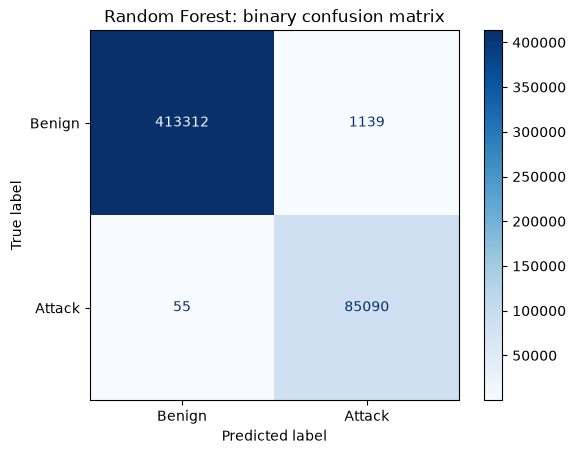


Decision Tree classification report
              precision    recall  f1-score   support

      Benign     0.9998    0.9973    0.9986    414451
      Attack     0.9871    0.9992    0.9931     85145

    accuracy                         0.9976    499596
   macro avg     0.9935    0.9983    0.9959    499596
weighted avg     0.9977    0.9976    0.9977    499596



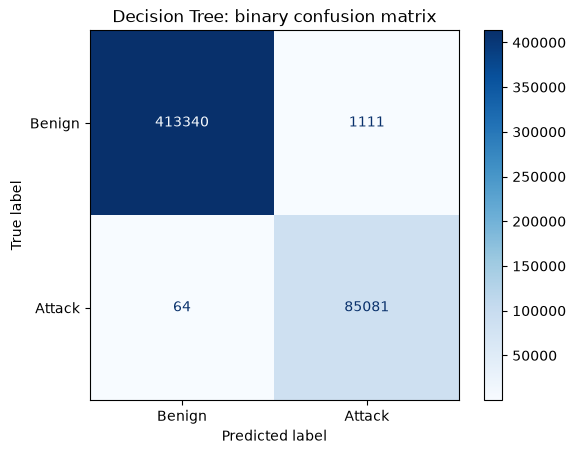


K-Nearest Neighbors classification report
              precision    recall  f1-score   support

      Benign     0.9948    0.9936    0.9942    414451
      Attack     0.9689    0.9746    0.9717     85145

    accuracy                         0.9903    499596
   macro avg     0.9818    0.9841    0.9830    499596
weighted avg     0.9904    0.9903    0.9903    499596



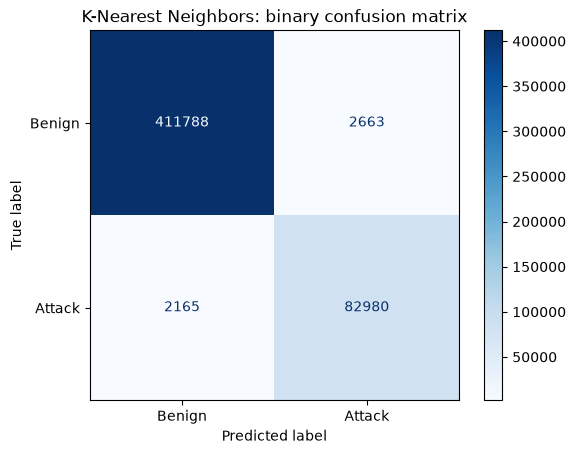

In [20]:
for name, output in binary_outputs.items():
    print(f"\n{name} classification report")
    print(classification_report(
        y_binary, output["predictions"], target_names=["Benign", "Attack"],
        digits=4, zero_division=0,
    ))
    ConfusionMatrixDisplay.from_predictions(
        y_binary, output["predictions"], display_labels=["Benign", "Attack"], cmap="Blues"
    )
    plt.title(f"{name}: binary confusion matrix")
    plt.show()

In [21]:
main_output = binary_outputs["Random Forest"]
binary_view = test[["attack_label", "attack_category", "is_attack"]].copy()
binary_view["predicted_is_attack"] = main_output["predictions"]
binary_view["attack_probability"] = main_output["attack_probability"]
binary_view["confidence"] = np.where(
    binary_view["predicted_is_attack"] == 1,
    binary_view["attack_probability"],
    1 - binary_view["attack_probability"],
)
binary_view["correct"] = binary_view["is_attack"] == binary_view["predicted_is_attack"]

correct_examples = binary_view[binary_view["correct"]].sample(10, random_state=RANDOM_STATE)
error_examples = binary_view[~binary_view["correct"]].head(10)
examples = pd.concat([correct_examples, error_examples]).reset_index(names="test_row")
display(examples.round({"attack_probability": 4, "confidence": 4}))

,test_row,attack_label,attack_category,is_attack,predicted_is_attack,attack_probability,confidence,correct
0,342904,BENIGN,BENIGN,0,0,0.0008,0.9992,True
1,380769,BENIGN,BENIGN,0,0,0.0191,0.9809,True
2,354739,BENIGN,BENIGN,0,0,0.0000,1.0000,True
3,97842,BENIGN,BENIGN,0,0,0.0000,1.0000,True
4,110810,BENIGN,BENIGN,0,0,0.0000,1.0000,True
5,4059,BENIGN,BENIGN,0,0,0.0002,0.9998,True
6,126631,BENIGN,BENIGN,0,0,0.0000,1.0000,True
7,376470,BENIGN,BENIGN,0,0,0.0000,1.0000,True
8,432138,BENIGN,BENIGN,0,0,0.0000,1.0000,True
9,242022,BENIGN,BENIGN,0,0,0.0000,1.0000,True


In [22]:
missed = binary_view[(binary_view["is_attack"] == 1) & (~binary_view["correct"])]
detection = pd.DataFrame({
    "attacks in test": y_category[y_category != "BENIGN"].value_counts(),
    "missed": missed["attack_category"].value_counts(),
}).fillna(0).astype(int)
detection["detection rate %"] = (
    (1 - detection["missed"] / detection["attacks in test"]) * 100
).round(3)
display(detection.sort_values("attacks in test", ascending=False))

,attacks in test,missed,detection rate %
attack_category,,,
DoS Hulk,34569,6,99.983
DDoS,25603,5,99.980
PortScan,18139,4,99.978
DoS GoldenEye,2056,3,99.854
FTP-Patator,1186,0,100.000
DoS slowloris,1075,5,99.535
DoS Slowhttptest,1046,2,99.809
SSH-Patator,644,1,99.845
Web Attack,428,9,97.897


## 3. The attack type

In [23]:
attack_model = joblib.load(ATTACK_MODEL_FILE)
attack_model.n_jobs = 1
attack_rows = test[test["is_attack"] == 1].copy()
x_attack = attack_rows[features]
y_attack = attack_rows["attack_category"].astype(str)

print(f"Model type:          {type(attack_model).__name__}")
print(f"Expected features:   {attack_model.n_features_in_}")
print(f"Attack test rows:    {len(attack_rows):,}")
print(f"Number of classes:   {len(attack_model.classes_)}")
print("Learned attack classes:")
for name in attack_model.classes_:
    print(f"  - {name}")

assert attack_model.n_features_in_ == len(features)
assert "BENIGN" not in attack_model.classes_
assert set(y_attack.unique()).issubset(set(attack_model.classes_))

Model type:          RandomForestClassifier
Expected features:   20
Attack test rows:    85,145
Number of classes:   12
Learned attack classes:
  - Bot
  - DDoS
  - DoS GoldenEye
  - DoS Hulk
  - DoS Slowhttptest
  - DoS slowloris
  - FTP-Patator
  - Heartbleed
  - Infiltration
  - PortScan
  - SSH-Patator
  - Web Attack


In [24]:
start = time.perf_counter()
attack_probabilities = attack_model.predict_proba(x_attack)
attack_predictions = attack_model.classes_[np.argmax(attack_probabilities, axis=1)]
attack_prediction_seconds = time.perf_counter() - start
attack_confidence = attack_probabilities.max(axis=1)

np.testing.assert_allclose(attack_probabilities.sum(axis=1), 1.0, atol=1e-6)

attack_metrics = pd.Series({
    "accuracy": accuracy_score(y_attack, attack_predictions),
    "precision_macro": precision_score(y_attack, attack_predictions, average="macro", zero_division=0),
    "recall_macro": recall_score(y_attack, attack_predictions, average="macro", zero_division=0),
    "f1_macro": f1_score(y_attack, attack_predictions, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_attack, attack_predictions, average="weighted", zero_division=0),
    "errors": int((attack_predictions != y_attack.to_numpy()).sum()),
    "prediction_seconds": attack_prediction_seconds,
}, name="value")
print("Attack-type classification results (true attack rows only)")
display(attack_metrics.to_frame().round(5))

attack_labels = sorted(set(attack_model.classes_) | set(pd.unique(y_attack)))
attack_per_class = pd.DataFrame(classification_report(
    y_attack, attack_predictions, labels=attack_labels,
    output_dict=True, zero_division=0,
)).transpose()
print("Per-class results")
display(attack_per_class.round(4))

Attack-type classification results (true attack rows only)


,value
accuracy,0.99942
precision_macro,0.99714
recall_macro,0.98520
f1_macro,0.99071
f1_weighted,0.99942
errors,49.00000
prediction_seconds,1.26189


Per-class results


,precision,recall,f1-score,support
Bot,0.9974,1.0000,0.9987,390.0000
DDoS,1.0000,0.9999,0.9999,25603.0000
DoS GoldenEye,0.9961,0.9971,0.9966,2056.0000
DoS Hulk,0.9995,0.9999,0.9997,34569.0000
DoS Slowhttptest,0.9943,0.9924,0.9933,1046.0000
DoS slowloris,0.9925,0.9907,0.9916,1075.0000
FTP-Patator,1.0000,1.0000,1.0000,1186.0000
Heartbleed,1.0000,1.0000,1.0000,2.0000
Infiltration,1.0000,0.8571,0.9231,7.0000
PortScan,0.9998,0.9994,0.9996,18139.0000


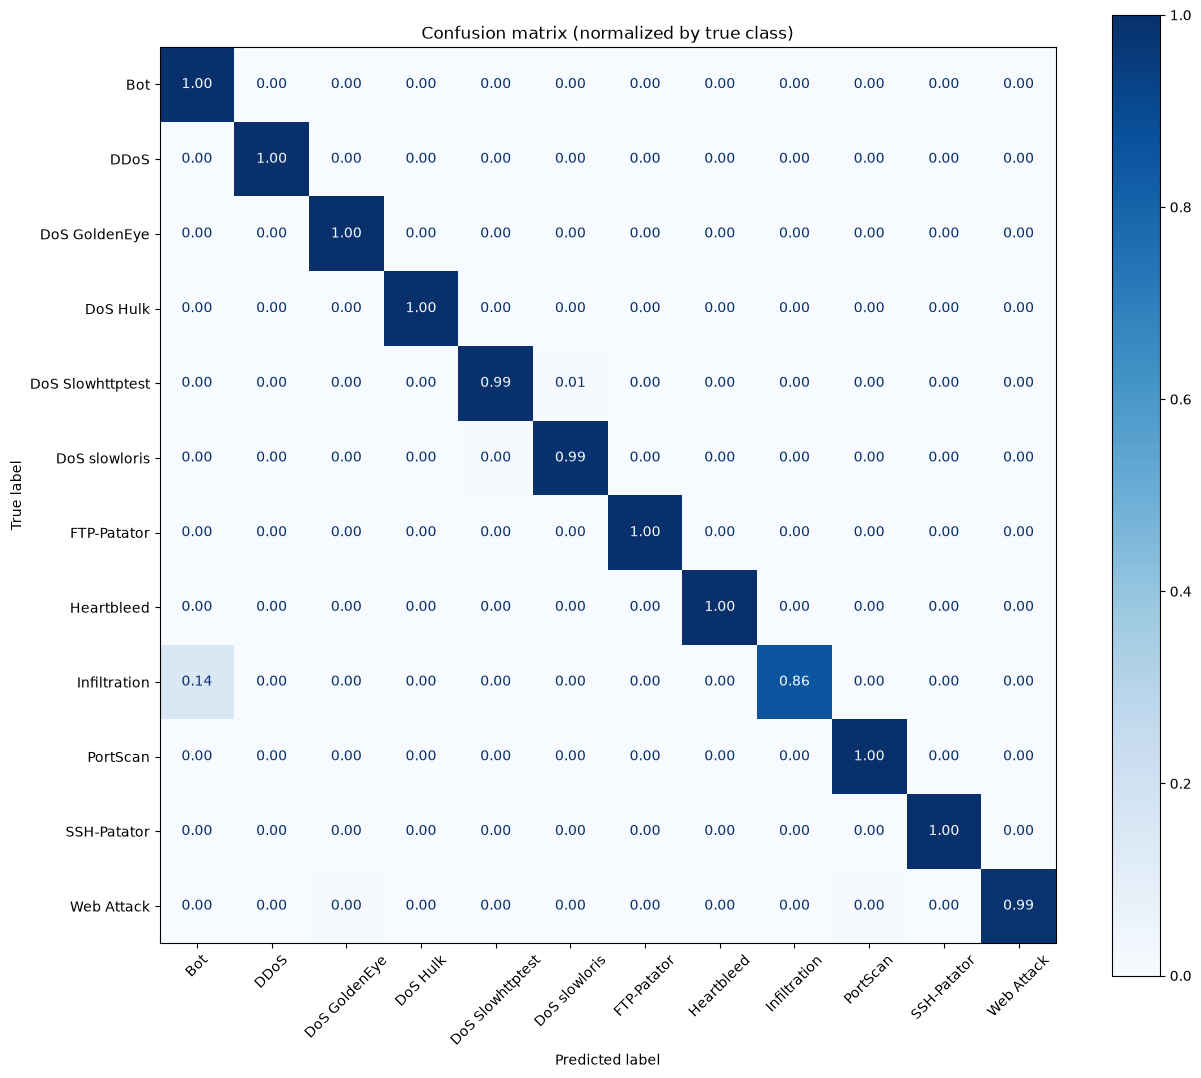

In [25]:
figure, axis = plt.subplots(figsize=(13, 11))
ConfusionMatrixDisplay.from_predictions(
    y_attack, attack_predictions, labels=attack_labels,
    display_labels=attack_labels, normalize="true", values_format=".2f",
    cmap="Blues", xticks_rotation=45, ax=axis,
)
axis.set_title("Confusion matrix (normalized by true class)")
plt.tight_layout()
plt.show()

In [26]:
attack_view = pd.DataFrame({
    "actual_attack": y_attack.to_numpy(),
    "predicted_attack": attack_predictions,
    "confidence": attack_confidence,
}, index=attack_rows.index)
attack_view["correct"] = attack_view["actual_attack"] == attack_view["predicted_attack"]

print("Two examples from every true attack class")
display(attack_view.groupby("actual_attack").head(2).reset_index(names="test_row").round(4))

errors = attack_view[~attack_view["correct"]]
print(f"Total attack-type classification errors: {len(errors):,}")
print("Most common confusion pairs:")
display(
    errors.groupby(["actual_attack", "predicted_attack"]).size()
    .sort_values(ascending=False).head(20).to_frame("rows")
)

Two examples from every true attack class


,test_row,actual_attack,predicted_attack,confidence,correct
0,6,DoS Hulk,DoS Hulk,1.0000,True
1,9,PortScan,PortScan,1.0000,True
2,13,PortScan,PortScan,1.0000,True
3,50,DDoS,DDoS,1.0000,True
4,58,DDoS,DDoS,1.0000,True
5,62,DoS Hulk,DoS Hulk,1.0000,True
6,150,DoS Slowhttptest,DoS Slowhttptest,1.0000,True
7,156,DoS slowloris,DoS slowloris,0.9667,True
8,174,DoS Slowhttptest,DoS Slowhttptest,1.0000,True
9,232,DoS GoldenEye,DoS GoldenEye,1.0000,True


Total attack-type classification errors: 49
Most common confusion pairs:


,,rows
actual_attack,predicted_attack,
DoS Slowhttptest,DoS slowloris,8
DoS GoldenEye,DoS Hulk,6
PortScan,DoS Hulk,6
DoS slowloris,DoS Slowhttptest,5
PortScan,Web Attack,4
DoS Hulk,DoS GoldenEye,4
DDoS,DoS Hulk,3
DoS slowloris,DoS GoldenEye,2
Web Attack,PortScan,2


## 4. The complete intrusion-detection system

In [27]:
binary_predictions = main_output["predictions"]
final_labels = np.full(len(test), "BENIGN", dtype=object)
alert_rows = np.flatnonzero(binary_predictions == 1)
final_labels[alert_rows] = attack_model.predict(x_test.iloc[alert_rows])

system_metrics = {
    "accuracy": accuracy_score(y_category, final_labels),
    "f1_macro": f1_score(y_category, final_labels, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_category, final_labels, average="weighted", zero_division=0),
    "incorrect_labels": int((final_labels != y_category.to_numpy()).sum()),
}

true_alert = (binary_predictions == 1) & (y_binary.to_numpy() == 1)
attack_type_accuracy_on_true_alerts = accuracy_score(
    y_category[true_alert], final_labels[true_alert]
)

print("Complete IDS results")
print(f"  Test rows:                      {len(test):,}")
print(f"  Flows identified as attacks:   {len(alert_rows):>10,}")
print(f"  Final accuracy:                 {system_metrics['accuracy']:.4%}")
print(f"  Final macro F1:                 {system_metrics['f1_macro']:.4f}")
print(f"  Final weighted F1:              {system_metrics['f1_weighted']:.4f}")
print(f"  Incorrect final labels:         {system_metrics['incorrect_labels']:,}")
print(f"  Attack-type accuracy on true alerts:{attack_type_accuracy_on_true_alerts:>10.4%}")

Complete IDS results
  Test rows:                      499,596
  Flows identified as attacks:       86,229
  Final accuracy:                 99.7532%
  Final macro F1:                 0.9436
  Final weighted F1:              0.9979
  Incorrect final labels:         1,233
  Attack-type accuracy on true alerts:  99.9542%


,precision,recall,f1-score,support
BENIGN,0.9999,0.9973,0.9986,414451.0000
Bot,0.7480,0.9513,0.8375,390.0000
DDoS,0.9997,0.9997,0.9997,25603.0000
DoS GoldenEye,0.9951,0.9956,0.9954,2056.0000
DoS Hulk,0.9964,0.9997,0.9981,34569.0000
DoS Slowhttptest,0.9904,0.9904,0.9904,1046.0000
DoS slowloris,0.9925,0.9898,0.9912,1075.0000
FTP-Patator,1.0000,1.0000,1.0000,1186.0000
Heartbleed,1.0000,1.0000,1.0000,2.0000
Infiltration,1.0000,0.8571,0.9231,7.0000


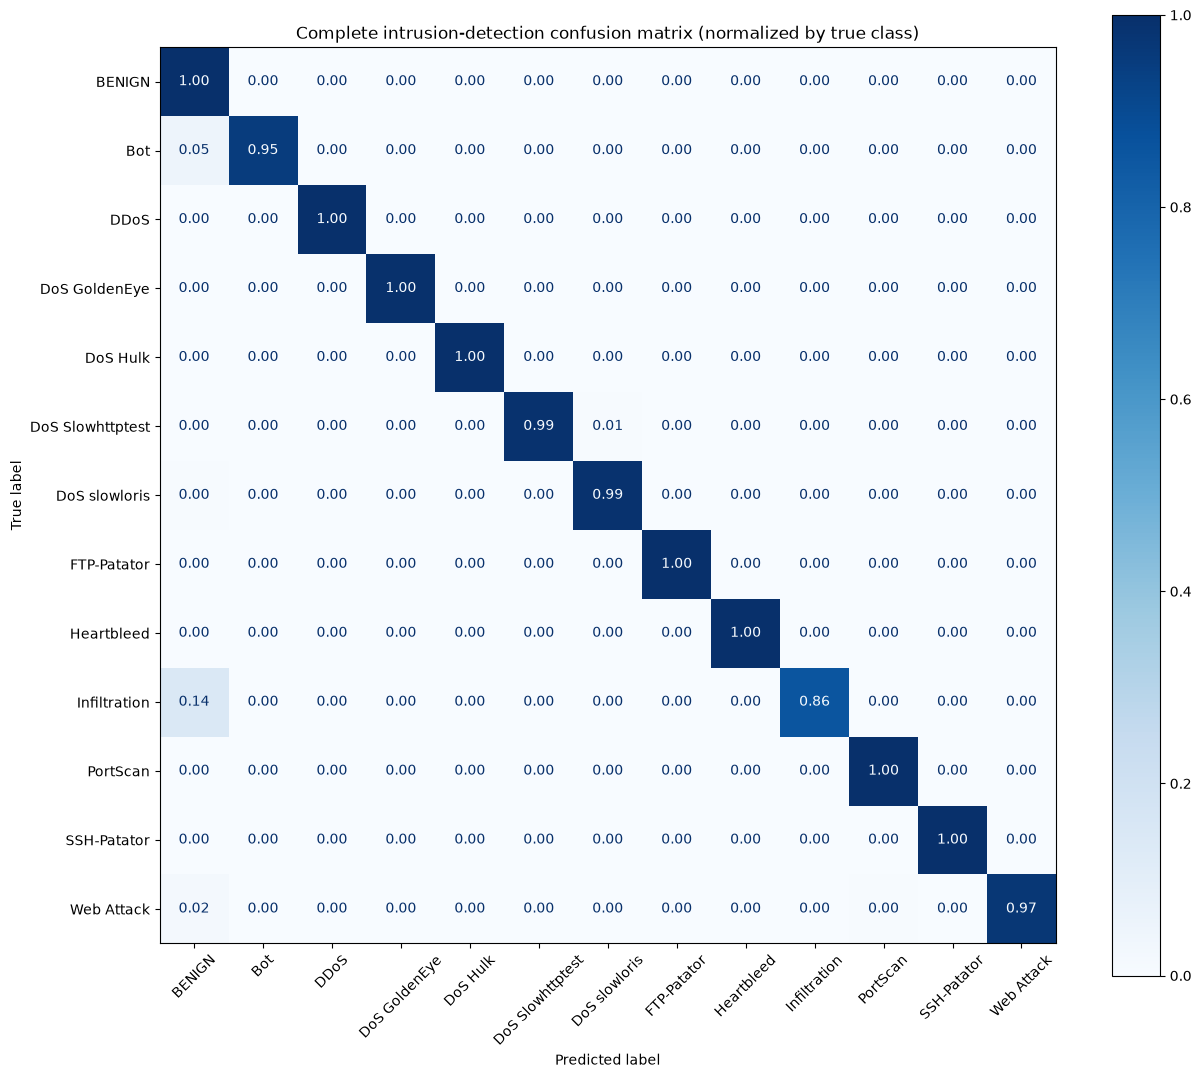

In [28]:
system_labels = sorted(set(y_category) | set(final_labels))
system_per_class = pd.DataFrame(classification_report(
    y_category, final_labels, labels=system_labels, output_dict=True, zero_division=0
)).transpose()
display(system_per_class.round(4))

figure, axis = plt.subplots(figsize=(13, 11))
ConfusionMatrixDisplay.from_predictions(
    y_category, final_labels, labels=system_labels, display_labels=system_labels,
    normalize="true", values_format=".2f", cmap="Blues", xticks_rotation=45, ax=axis,
)
axis.set_title("Complete intrusion-detection confusion matrix (normalized by true class)")
plt.tight_layout()
plt.show()

## 5. Save the evaluation results

In [29]:
EVALUATION_FOLDER.mkdir(parents=True, exist_ok=True)

binary_results.to_csv(
    EVALUATION_FOLDER / "binary_intrusion_detection_model_comparison.csv"
)
system_per_class.to_csv(
    EVALUATION_FOLDER / "complete_intrusion_detection_per_class_metrics.csv"
)
figure.savefig(
    EVALUATION_FOLDER / "complete_intrusion_detection_confusion_matrix.png",
    dpi=150,
)

evaluation_report = {
    "test_rows": len(test),
    "alerts": int(len(alert_rows)),
    "classes": system_labels,
    "binary_intrusion_detection_models": binary_results.reset_index().to_dict(orient="records"),
    "attack_type_classification_on_true_attack_rows": {
        key: float(value) for key, value in attack_metrics.items()
    },
    "attack_type_classification_accuracy_on_true_alerts": float(
        attack_type_accuracy_on_true_alerts
    ),
    "complete_system": system_metrics,
}
(EVALUATION_FOLDER / "complete_intrusion_detection_report.json").write_text(
    json.dumps(evaluation_report, indent=2), encoding="utf-8"
)

def markdown_table(frame):
    """Build a Markdown table without an extra library."""
    columns = [frame.index.name or ""] + [str(column) for column in frame.columns]
    lines = [
        "| " + " | ".join(columns) + " |",
        "| " + " | ".join(["---"] * len(columns)) + " |",
    ]
    for name, row in zip(frame.index, frame.to_numpy()):
        cells = [str(name)] + [f"{value:.4f}" for value in row]
        lines.append("| " + " | ".join(cells) + " |")
    return "\n".join(lines)


comparison = binary_results[["accuracy", "precision", "recall", "f1_score"]].round(4)
comparison.columns = ["Accuracy", "Precision", "Recall", "F1-score"]
print("Binary intrusion-detection comparison table")
print(markdown_table(comparison))
# print(f"\nSaved in {EVALUATION_FOLDER}")

Binary intrusion-detection comparison table
| model | Accuracy | Precision | Recall | F1-score |
| --- | --- | --- | --- | --- |
| Random Forest | 0.9976 | 0.9868 | 0.9994 | 0.9930 |
| Decision Tree | 0.9976 | 0.9871 | 0.9992 | 0.9931 |
| K-Nearest Neighbors | 0.9903 | 0.9689 | 0.9746 | 0.9717 |
